# UFC Winner Prediction — Modeling Pipeline (Pre-fight features only)

This notebook builds models to predict fight winners using **only pre-fight features** from `/mnt/data/ufc-master.csv`.

In [2]:
# 1. Setup
import pandas as pd, numpy as np
csv_path = "ufc-master.csv"
df = pd.read_csv(csv_path)
print("Loaded:", df.shape)
df.head()

Loaded: (6541, 118)


,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,...,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Colby Covington,Joaquin Buckley,205.0,-250.0,205.0000,40.0000,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,NaN,3.0,4:42,882.0,300.0,175.0,1800.0,2000.0,1100.0,150.0
1,Cub Swanson,Billy Quarantillo,124.0,-148.0,124.0000,67.5676,2024-12-14,"Tampa, Florida, USA",USA,Red,...,Punch,3.0,1:36,696.0,250.0,NaN,1800.0,NaN,450.0,NaN
2,Manel Kape,Bruno Silva,-395.0,310.0,25.3165,310.0000,2024-12-14,"Tampa, Florida, USA",USA,Red,...,Punches,3.0,1:57,717.0,-105.0,550.0,900.0,1800.0,225.0,1100.0
3,Vitor Petrino,Dustin Jacoby,-340.0,270.0,29.4118,270.0000,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,Punch,3.0,3:44,824.0,240.0,500.0,550.0,3000.0,110.0,800.0
4,Adrian Yanez,Daniel Marcos,185.0,-225.0,185.0000,44.4444,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,NaN,3.0,5:00,900.0,450.0,150.0,2200.0,2200.0,450.0,200.0


In [3]:
# 2. Quick column inspection
print("Columns (first 80):", list(df.columns)[:80])
for key in ['Blue','Red','Dif','Odds','Stance','WeightClass','TitleBout','Reach','Height','Age']:
    cols = [c for c in df.columns if key in c]
    if cols:
        print(f"\nColumns containing '{key}': {cols[:10]}{'...' if len(cols)>10 else ''}")

Columns (first 80): ['RedFighter', 'BlueFighter', 'RedOdds', 'BlueOdds', 'RedExpectedValue', 'BlueExpectedValue', 'Date', 'Location', 'Country', 'Winner', 'TitleBout', 'WeightClass', 'Gender', 'NumberOfRounds', 'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 'BlueLongestWinStreak', 'BlueLosses', 'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority', 'BlueWinsByDecisionSplit', 'BlueWinsByDecisionUnanimous', 'BlueWinsByKO', 'BlueWinsBySubmission', 'BlueWinsByTKODoctorStoppage', 'BlueWins', 'BlueStance', 'BlueHeightCms', 'BlueReachCms', 'BlueWeightLbs', 'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws', 'RedAvgSigStrLanded', 'RedAvgSigStrPct', 'RedAvgSubAtt', 'RedAvgTDLanded', 'RedAvgTDPct', 'RedLongestWinStreak', 'RedLosses', 'RedTotalRoundsFought', 'RedTotalTitleBouts', 'RedWinsByDecisionMajority', 'RedWinsByDecisionSplit', 'RedWinsByDecisionUnanimo

In [4]:
# 3. Create target and mark leakage columns
df['BlueWin'] = (df['Winner'] == 'Blue').astype(int)
leak_cols = [c for c in df.columns if any(x in c for x in ['Finish','FinishRound','FinishRoundTime','TotalFightTime','TotalFightTimeSecs'])]
print("Leak/post-fight columns detected:", leak_cols)

Leak/post-fight columns detected: ['Finish', 'FinishDetails', 'FinishRound', 'FinishRoundTime', 'TotalFightTimeSecs']


In [5]:
# 4. Select pre-fight features programmatically
cols = df.columns.tolist()
exclude = set(['Winner','BlueWin','RedFighter','BlueFighter','Date','Location','EmptyArena'])
exclude |= set([c for c in cols if any(x in c for x in ['Finish','TotalFightTime','Referee', 'weightRank', 'FPRank'])])
exclude |= set(leak_cols)
include_keywords = ['Blue','Red','Dif','Odds','Implied','Age','Reach','Height','Weight','Stance','Rank','TitleBout','WeightClass','NumberOfRounds','Country','Gender']

feature_cols = [c for c in cols if (c not in exclude) and any(k in c for k in include_keywords)]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
print("Selected features:", len(feature_cols))
print("Numeric sample:", numeric_cols[:20])
print("Categorical sample:", categorical_cols[:20])

Selected features: 81
Numeric sample: ['RedOdds', 'BlueOdds', 'RedExpectedValue', 'BlueExpectedValue', 'TitleBout', 'NumberOfRounds', 'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 'BlueLongestWinStreak', 'BlueLosses', 'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority', 'BlueWinsByDecisionSplit']
Categorical sample: ['Country', 'WeightClass', 'Gender', 'BlueStance', 'RedStance', 'BetterRank']


In [6]:
from sklearn.model_selection import train_test_split
X = df[feature_cols].copy()
y = df['BlueWin'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train/test:", X_train.shape, X_test.shape)

Train/test: (5232, 81) (1309, 81)


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_cols),
                                  ('cat', categorical_transformer, categorical_cols)], sparse_threshold=0)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
models = {
    'LogisticRegression': Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),
    'RandomForest': Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))]),
    'GradientBoosting': Pipeline([('pre', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))]),
    'MLP': Pipeline([('pre', preprocessor), ('clf', MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42))])
}
# Try to add XGBoost if available
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])
    print("XGBoost added")
except Exception as e:
    print("XGBoost not available:", e)

XGBoost added


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','f1','roc_auc']

import numpy as np
for name, model in models.items():
    print("\nModel:", name)
    try:
        acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
        f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        print("Accuracy: %.4f ± %.4f" % (acc.mean(), acc.std()))
        print("F1: %.4f ± %.4f" % (f1.mean(), f1.std()))
        print("ROC AUC: %.4f ± %.4f" % (roc.mean(), roc.std()))
    except Exception as e:
        print("Error CV for", name, e)


Model: LogisticRegression
Accuracy: 0.6326 ± 0.0130
F1: 0.5937 ± 0.0114
ROC AUC: 0.6951 ± 0.0138

Model: RandomForest
Accuracy: 0.6527 ± 0.0092
F1: 0.5423 ± 0.0071
ROC AUC: 0.6942 ± 0.0127

Model: GradientBoosting
Accuracy: 0.6476 ± 0.0198
F1: 0.5399 ± 0.0251
ROC AUC: 0.6925 ± 0.0173

Model: MLP
Accuracy: 0.5873 ± 0.0100
F1: 0.4992 ± 0.0115
ROC AUC: 0.6055 ± 0.0102

Model: XGBoost


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:26:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:26:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:26:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:26:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

Accuracy: 0.6271 ± 0.0104
F1: 0.5263 ± 0.0182
ROC AUC: 0.6616 ± 0.0118


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
results = []
for name, model in models.items():
    print("\nTraining:", name)
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if hasattr(model.named_steps['clf'], 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:,1]
        else:
            y_proba = None
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')
        print(f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
        results.append({'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc})
    except Exception as e:
        print("Error training/evaluating", name, e)

import pandas as pd
print("\nSummary:")
display(pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False))


Training: LogisticRegression
Acc: 0.6394 | Prec: 0.5631 | Rec: 0.6327 | F1: 0.5959 | ROC-AUC: 0.7105
Confusion matrix:
 [[489 270]
 [202 348]]

Training: RandomForest
Acc: 0.6547 | Prec: 0.6099 | Rec: 0.4945 | F1: 0.5462 | ROC-AUC: 0.7107
Confusion matrix:
 [[585 174]
 [278 272]]

Training: GradientBoosting
Acc: 0.6600 | Prec: 0.6180 | Rec: 0.5000 | F1: 0.5528 | ROC-AUC: 0.7166
Confusion matrix:
 [[589 170]
 [275 275]]

Training: MLP
Acc: 0.5951 | Prec: 0.5189 | Rec: 0.5000 | F1: 0.5093 | ROC-AUC: 0.6230
Confusion matrix:
 [[504 255]
 [275 275]]

Training: XGBoost
Acc: 0.6303 | Prec: 0.5673 | Rec: 0.5055 | F1: 0.5346 | ROC-AUC: 0.6675
Confusion matrix:
 [[547 212]
 [272 278]]

Summary:


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:26:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.639419,0.563107,0.632727,0.595890,0.710476
GradientBoosting,0.660046,0.617978,0.500000,0.552764,0.716577
RandomForest,0.654698,0.609865,0.494545,0.546185,0.710690
XGBoost,0.630252,0.567347,0.505455,0.534615,0.667517
MLP,0.595111,0.518868,0.500000,0.509259,0.622992


RedExpectedValue         0.043456
BlueOdds                 0.039609
RedOdds                  0.039547
BlueExpectedValue        0.037390
BlueDecOdds              0.025629
BKOOdds                  0.022499
SigStrDif                0.022491
AvgTDDif                 0.022184
RedDecOdds               0.022096
RKOOdds                  0.021802
RedAvgSigStrLanded       0.021728
BlueAvgSigStrPct         0.021181
RSubOdds                 0.021168
RedAvgSigStrPct          0.021062
BlueAvgSigStrLanded      0.019316
BSubOdds                 0.019042
AvgSubAttDif             0.017624
RedAvgTDPct              0.017527
RedAvgTDLanded           0.017524
BlueAge                  0.016903
RedAge                   0.016847
AgeDif                   0.016710
BlueAvgTDLanded          0.016298
TotalRoundDif            0.016130
ReachDif                 0.015396
RedTotalRoundsFought     0.015119
BlueReachCms             0.014627
RedReachCms              0.014410
BlueAvgTDPct             0.014406
RedAvgSubAtt  

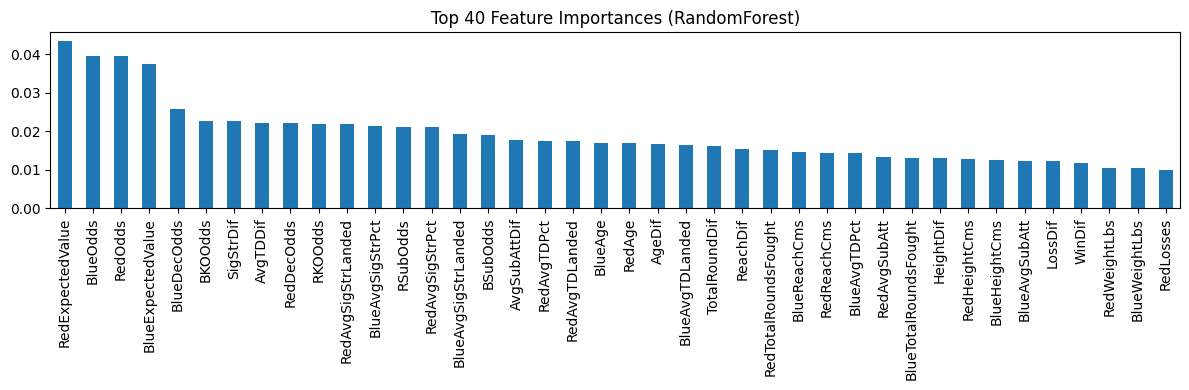

In [11]:
import matplotlib.pyplot as plt
# Feature importances for tree-based models (example for RandomForest)
def get_feature_names(preprocessor):
    num_names = list(preprocessor.transformers_[0][2])
    cat_trans = preprocessor.transformers_[1][1]
    if hasattr(cat_trans.named_steps['ohe'], 'get_feature_names_out'):
        cat_names = list(cat_trans.named_steps['ohe'].get_feature_names_out(preprocessor.transformers_[1][2]))
    else:
        cat_names = []
    return num_names + cat_names

if 'RandomForest' in models:
    try:
        rf = models['RandomForest']
        pre = rf.named_steps['pre']
        clf = rf.named_steps['clf']
        feat_names = get_feature_names(pre)
        imp = clf.feature_importances_
        importances = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(40)
        display(importances)
        importances.plot(kind='bar', figsize=(12,4))
        plt.title('Top 40 Feature Importances (RandomForest)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Could not compute feature importances:", e)